# Business Analytics and Visualisation — Assessment 1, Part 1

Student ID: s8200703
Dataset: AusiFood_Foodsupplier.xlsx
Course level: MSc Business Analytics
Purpose: Complete the Session 3 analysis using reproducible, readable, and professionally structured Python code.
Required outputs

    Count the original columns before creating any new columns.
    Calculate total profit by year.
    Calculate total profit by supplier state/territory.
    Calculate monthly sales by supplier state/territory, pooling the same month across all years and ordering by Month Number.
    Calculate and visualise units sold by item in 2017.
    Provide a 200-word business discussion.

    Keep the Excel workbook in the same folder as this notebook before running all cells.


## 1. Import the required libraries

pandas is used for importing and analysing the data. seaborn and matplotlib are used to create clear visualisations.

In [122]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## 2. Import the Excel dataset and Print Rows & Column count

The workbook is imported with pandas.read_excel(). The DataFrame is named s8200703 using the student ID. Then the row and column count is printed.

In [123]:
s8200703 = pd.read_excel("AusiFood_Foodsupplier.xlsx")

print("Dataset imported successfully.")
print(f"Number of rows: {s8200703.shape[0]:,}")
print(f"Number of columns: {s8200703.shape[1]}")

Dataset imported successfully.
Number of rows: 900
Number of columns: 21


## 3. Preview the dataset

The first five rows are displayed to confirm that the data loaded correctly and to understand the variables.

In [124]:
s8200703.head().set_axis(
    range(1, len(s8200703.head()) + 1),
    axis="index"
)

,Item_id,Item,Category,Store,Supplier,Supplier location,City,Payment method,quantity,Item sold,...,total cost,sold price,Discounts,total sales,Date,Month Number,Month Name,Year,product feedback,other feedback
1,1122,Bulk Almonds 15kg,Bulk & Pantry,Grocery,Mediterranean Wholesalers,VIC,Kensington and Flemington,credit_card,58,57,...,9570.0,188.10,0.00,10721.70,2017-01-02,1,January,2017,neutral,order was as expected
2,1123,Tomatoes,Vegetables,Market,Kahvecioglu Grand Foods,Tasmania,Northcote,cash,556,556,...,1112.0,2.86,79.51,1510.65,2017-01-02,1,January,2017,strongly disagree,no one responded to my email
3,1124,Tomatoes,Vegetables,Market,Kahvecioglu Grand Foods,VIC,Northcote,credit_card,1906,1864,...,3812.0,2.86,186.59,5144.45,2017-01-03,1,January,2017,agree,I like your product
4,1125,Cheese,Dairy & Eggs,Home Delivery,First Ray,Australian Capital Territory,Southbank,credit_card,876,834,...,4380.0,6.37,265.63,5046.95,2017-01-06,1,January,2017,agree,I like your product
5,1126,Sour cream,Dairy & Eggs,Home Delivery,Basfoods Direct - Somerton Store,Tasmania,Kensington and Flemington,credit_card,217,202,...,1302.0,6.60,66.66,1266.54,2017-01-10,1,January,2017,neutral,no comment


## 4. Inspect the dataset structure

The info() method displays column names, data types, and non-missing values.

In [125]:
s8200703.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Item_id            900 non-null    int64         
 1   Item               900 non-null    object        
 2   Category           900 non-null    object        
 3   Store              900 non-null    object        
 4   Supplier           900 non-null    object        
 5   Supplier location  900 non-null    object        
 6   City               900 non-null    object        
 7   Payment method     900 non-null    object        
 8   quantity           900 non-null    int64         
 9   Item sold          900 non-null    int64         
 10  purchase price     900 non-null    float64       
 11  total cost         900 non-null    float64       
 12  sold price         900 non-null    float64       
 13  Discounts          900 non-null    float64       
 14  total sale

## 5. Identify the original number of columns (Answer to Total number of columns in the data set as supplied, before you add any columns of your own)

This value is recorded before adding any calculated columns.



In [126]:
original_column_count = s8200703.shape[1]
print(f"Total number of original columns: {original_column_count}")

Total number of original columns: 21


## 6. Check data quality

The dataset is checked for missing values and fully duplicated rows before analysis.

In [127]:
total_missing_values = s8200703.isna().sum().sum()
total_duplicate_rows = s8200703.duplicated().sum()

print(f"Total missing values: {total_missing_values}")
print(f"Total duplicated rows: {total_duplicate_rows}")

Total missing values: 0
Total duplicated rows: 0


## 7. Create a working copy

A separate DataFrame named s8200703_analysis is created so the original imported data remains unchanged.

In [128]:
s8200703_analysis = s8200703.copy()
print("Working DataFrame created successfully.")

Working DataFrame created successfully.


## 8. Standardise supplier state and territory names

The supplier-location values are converted to standard Australian abbreviations for consistency.

In [129]:
state_abbreviations = {
    "Victoria": "VIC", "VIC": "VIC",
    "New South Wales": "NSW", "NSW": "NSW",
    "Queensland": "QLD", "QLD": "QLD",
    "Western Australia": "WA", "WA": "WA",
    "South Australia": "SA", "SA": "SA",
    "Tasmania": "TAS", "TAS": "TAS",
    "Northern Territory": "NT", "NT": "NT",
    "Australian Capital Territory": "ACT", "ACT": "ACT"
}

s8200703_analysis["Supplier location"] = (
    s8200703_analysis["Supplier location"].replace(state_abbreviations)
)

print(sorted(s8200703_analysis["Supplier location"].unique()))

['ACT', 'NSW', 'NT', 'QLD', 'SA', 'TAS', 'VIC', 'WA']


## 9. Create new column for Profit

In [130]:
s8200703_analysis["Profit"] = (
    s8200703_analysis["total sales"]
    - s8200703_analysis["total cost"]
)

print("Profit column created successfully.")

Profit column created successfully.


In [131]:
new_column_count = s8200703_analysis.shape[1]

print(f"Original number of columns: {original_column_count}")
print(f"New number of columns after adding Profit: {new_column_count}")

Original number of columns: 21
New number of columns after adding Profit: 22


## 10. Preview Profit Column

Profit is calculated as total sales minus total cost and rounded to two decimal places for ease of calculation and viewing.

In [132]:
display(
    s8200703_analysis[
        ["total sales", "total cost", "Profit"]
    ]
    .head()
    .set_axis(range(1, 6), axis="index")
    .style
    .format(
        {
            "total sales": "${:,.2f}",
            "total cost": "${:,.2f}",
            "Profit": "${:,.2f}"
        }
    )
)

,total sales,total cost,Profit
1,"$10,721.70","$9,570.00","$1,151.70"
2,"$1,510.65","$1,112.00",$398.65
3,"$5,144.45","$3,812.00","$1,332.45"
4,"$5,046.95","$4,380.00",$666.95
5,"$1,266.54","$1,302.00",$-35.46


## 11. Calculate total profit by year (Answer to Total profit the company makes in each year, where profit = total sales − total cost. Report one figure per year)

The data is grouped by Year, profit is summed, and the final values are rounded to two decimal places.

In [133]:
profit_by_year = (
    s8200703_analysis
    .groupby("Year", as_index=False, sort=True)
    .agg(Total_Profit=("Profit", "sum"))
    .sort_values("Year")
    .reset_index(drop=True)
)

profit_by_year["Total_Profit"] = profit_by_year["Total_Profit"].round(2)

print("Total Profit by Year:")
print(profit_by_year)

Total Profit by Year:
   Year  Total_Profit
0  2017     285577.92
1  2018     336647.32
2  2019     379687.79
3  2020     495007.58
4  2021     637769.17


### Rounding up to nearest dollar value

In [134]:
profit_by_year["Total_Profit"] = (
    profit_by_year["Total_Profit"].round(0)
)

# Change the displayed row numbers so they start from 1
profit_by_year.index = range(1, len(profit_by_year) + 1)
profit_by_year.index.name = "Serial Number"

print("Total Profit by Year Rounded to the Nearest Dollar:")
print(profit_by_year)

Total Profit by Year Rounded to the Nearest Dollar:
               Year  Total_Profit
Serial Number                    
1              2017      285578.0
2              2018      336647.0
3              2019      379688.0
4              2020      495008.0
5              2021      637769.0


## Visualisation: Total profit by year

A vertical bar chart compares company profit across the five years.

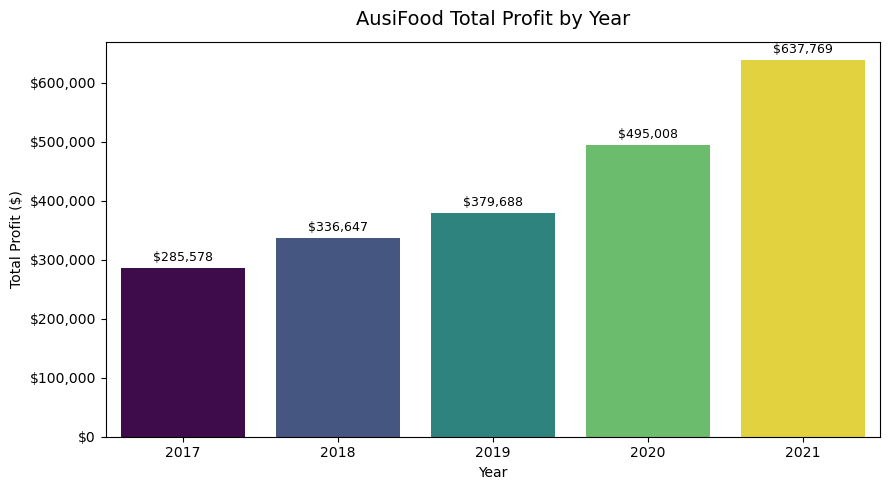

In [135]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=profit_by_year,
    x="Year",
    y="Total_Profit",
    hue="Year",
    palette="viridis",
    legend=False
)

ax.set_title("AusiFood Total Profit by Year", fontsize=14, pad=12)
ax.set_xlabel("Year")
ax.set_ylabel("Total Profit ($)")

ax.yaxis.set_major_formatter(
    lambda value, position: f"${value:,.0f}"
)

# Add a label above each actual bar
for bar in ax.patches:
    height = bar.get_height()

    if pd.notna(height):
        ax.annotate(
            f"${height:,.0f}",
            xy=(
                bar.get_x() + bar.get_width() / 2,
                height
            ),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.show()

### Interpretation
Total profit increased every year from 2017 to 2021, indicating strong improvement in AusiFood’s overall financial performance.

## 12. Calculate total profit by supplier state or territory (Answer to Total profit for each state, using the Supplier location column. Repeating the analysis by City is optional)

The analysis uses the standardised Supplier location column and ranks locations from highest to lowest profit. Figures have been rounded up to nearest dollar value.

In [136]:
profit_by_state = (
    s8200703_analysis
    .groupby("Supplier location", as_index=False)
    .agg(Total_Profit=("Profit", "sum"))
    .sort_values("Total_Profit", ascending=False)
    .reset_index(drop=True)
)

# Round up to the next whole dollar without importing NumPy
profit_by_state["Total_Profit"] = (
    profit_by_state["Total_Profit"]
    .apply(
        lambda value: int(value)
        if value == int(value)
        else int(value) + 1
    )
)

print("Total Profit by Supplier State or Territory:")

display(
    profit_by_state.style
    .format({"Total_Profit": "${:,.0f}"})
    .hide(axis="index")
)

Total Profit by Supplier State or Territory:


Supplier location,Total_Profit
VIC,"$752,575"
NSW,"$338,492"
QLD,"$328,936"
WA,"$220,718"
SA,"$165,375"
ACT,"$128,736"
TAS,"$126,235"
NT,"$73,626"


## Visualisation: Total profit by supplier state or territory

A horizontal green bar chart clearly shows the ranking of all states and territories.

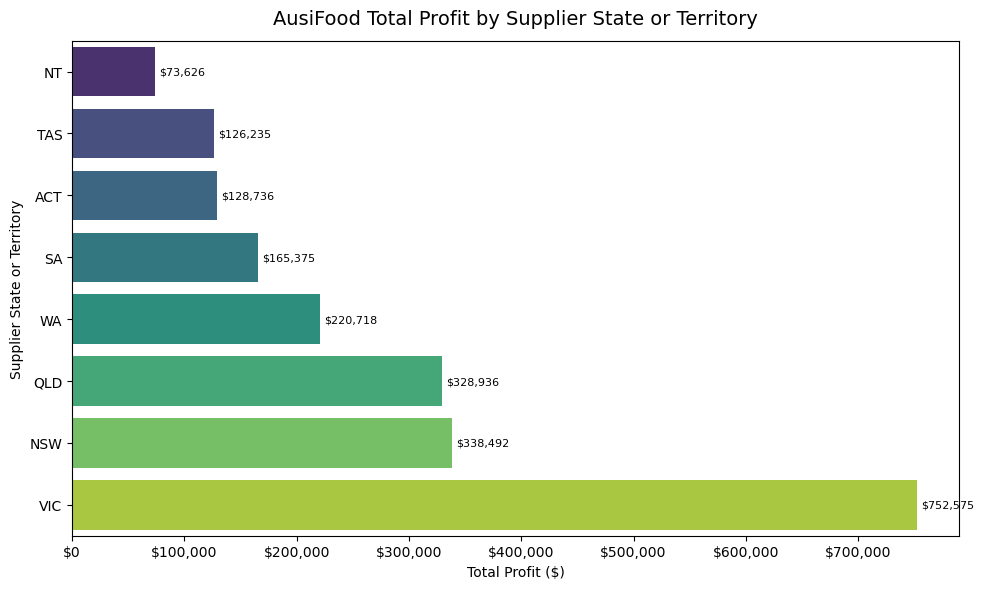

In [137]:
state_plot_data = profit_by_state.sort_values(
    "Total_Profit",
    ascending=True
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=state_plot_data,
    x="Total_Profit",
    y="Supplier location",
    hue="Supplier location",
    palette="viridis",
    legend=False
)

ax.set_title(
    "AusiFood Total Profit by Supplier State or Territory",
    fontsize=14,
    pad=12
)

ax.set_xlabel("Total Profit ($)")
ax.set_ylabel("Supplier State or Territory")

ax.xaxis.set_major_formatter(
    lambda value, position: f"${value:,.0f}"
)

# Add labels to each horizontal bar
for bar in ax.patches:
    width = bar.get_width()

    if pd.notna(width):
        ax.annotate(
            f"${width:,.0f}",
            xy=(
                width,
                bar.get_y() + bar.get_height() / 2
            ),
            xytext=(3, 0),
            textcoords="offset points",
            ha="left",
            va="center",
            fontsize=8
        )

plt.tight_layout()
plt.show()

## Interpretation

Victoria generated the highest total profit, while the Northern Territory generated the lowest. This shows substantial geographic variation in profitability.

## 13. Calculate monthly sales by supplier state or territory (Answer to Total monthly sales in dollars for each state, with the twelve months pooled across all years. Order the months by Month Number, not by month name)

The same calendar month is pooled across all years. Grouping by Month Number keeps the months in chronological order. The total sales is also shown rounded off to the nearest dollar value

In [138]:
monthly_sales_long = (
    s8200703_analysis
    .groupby(
        ["Month Number", "Supplier location"],
        as_index=False
    )
    .agg(Total_Sales=("total sales", "sum"))
    .sort_values(
        ["Month Number", "Supplier location"]
    )
    .reset_index(drop=True)
)

# Round sales to the nearest dollar
monthly_sales_long["Total_Sales"] = (
    monthly_sales_long["Total_Sales"].round(0)
)

# Convert the results into a comparison table
monthly_sales_table = (
    monthly_sales_long
    .pivot(
        index="Month Number",
        columns="Supplier location",
        values="Total_Sales"
    )
    .reindex(range(1, 13))
)

# Add month names for readability
month_names = {
    1: "JAN",
    2: "FEB",
    3: "MAR",
    4: "APR",
    5: "MAY",
    6: "JUN",
    7: "JUL",
    8: "AUG",
    9: "SEP",
    10: "OCT",
    11: "NOV",
    12: "DEC"
}

monthly_sales_table.insert(
    0,
    "Month Name",
    monthly_sales_table.index.map(month_names)
)

print("Monthly Sales by Supplier State or Territory:")

display(
    monthly_sales_table.style.format(
        {
            column: "${:,.0f}"
            for column in monthly_sales_table.columns
            if column != "Month Name"
        }
    )
)

Monthly Sales by Supplier State or Territory:


Supplier location,Month Name,ACT,NSW,NT,QLD,SA,TAS,VIC,WA
Month Number,,,,,,,,,
1,JAN,"$65,633","$266,020","$11,992","$126,963","$205,671","$18,041","$358,876","$168,826"
2,FEB,"$115,954","$111,526","$117,494","$190,899","$115,482","$67,583","$521,676","$141,765"
3,MAR,"$47,466","$203,623","$44,184","$48,541","$51,725","$120,638","$559,362","$37,408"
4,APR,"$274,957","$395,377","$10,135","$177,415","$91,496","$210,976","$359,296","$249,544"
5,MAY,"$45,864","$321,739","$11,712","$177,249","$84,338","$32,276","$356,397","$87,798"
6,JUN,"$74,057","$113,552","$64,783","$253,305","$30,853","$96,035","$486,896","$70,510"
7,JUL,"$33,546","$202,734","$27,516","$103,332","$121,919","$59,005","$546,676","$60,002"
8,AUG,"$74,315","$187,205","$73,852","$181,537","$65,305","$74,678","$462,700","$110,452"
9,SEP,"$110,691","$254,836","$30,653","$96,806","$59,812","$52,638","$386,807","$124,480"


## 14. Present monthly sales as a pivot table

Month numbers are shown in rows and supplier locations in columns to support direct comparison.

In [139]:
monthly_sales_by_state = (
    monthly_sales_long
    .pivot(
        index="Month Number",
        columns="Supplier location",
        values="Total_Sales"
    )
    .reindex(range(1, 13))
    .round(0)
)

month_names = {
    1: "JAN",
    2: "FEB",
    3: "MAR",
    4: "APR",
    5: "MAY",
    6: "JUN",
    7: "JUL",
    8: "AUG",
    9: "SEP",
    10: "OCT",
    11: "NOV",
    12: "DEC"
}

monthly_sales_by_state.insert(
    0,
    "Month Name",
    monthly_sales_by_state.index.map(month_names)
)

monthly_sales_by_state.index.name = "Month Number"

print("Monthly Sales by Supplier State or Territory:")

display(
    monthly_sales_by_state.style.format(
        {
            column: "${:,.0f}"
            for column in monthly_sales_by_state.columns
            if column != "Month Name"
        }
    )
)

Monthly Sales by Supplier State or Territory:


Supplier location,Month Name,ACT,NSW,NT,QLD,SA,TAS,VIC,WA
Month Number,,,,,,,,,
1,JAN,"$65,633","$266,020","$11,992","$126,963","$205,671","$18,041","$358,876","$168,826"
2,FEB,"$115,954","$111,526","$117,494","$190,899","$115,482","$67,583","$521,676","$141,765"
3,MAR,"$47,466","$203,623","$44,184","$48,541","$51,725","$120,638","$559,362","$37,408"
4,APR,"$274,957","$395,377","$10,135","$177,415","$91,496","$210,976","$359,296","$249,544"
5,MAY,"$45,864","$321,739","$11,712","$177,249","$84,338","$32,276","$356,397","$87,798"
6,JUN,"$74,057","$113,552","$64,783","$253,305","$30,853","$96,035","$486,896","$70,510"
7,JUL,"$33,546","$202,734","$27,516","$103,332","$121,919","$59,005","$546,676","$60,002"
8,AUG,"$74,315","$187,205","$73,852","$181,537","$65,305","$74,678","$462,700","$110,452"
9,SEP,"$110,691","$254,836","$30,653","$96,806","$59,812","$52,638","$386,807","$124,480"


## Visualisation: Monthly sales by supplier state or territory

A multi-line chart is used because month order is important. Each line represents one supplier state or territory.

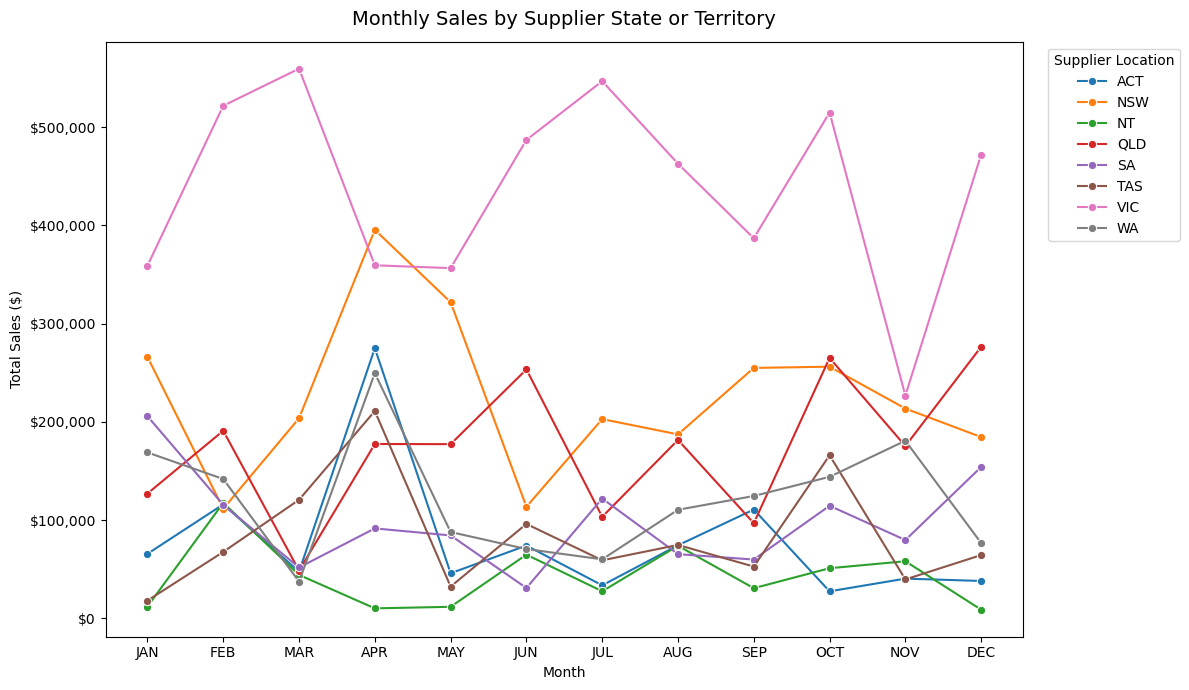

In [140]:
month_short_names = {
    1: "JAN", 2: "FEB", 3: "MAR", 4: "APR",
    5: "MAY", 6: "JUN", 7: "JUL", 8: "AUG",
    9: "SEP", 10: "OCT", 11: "NOV", 12: "DEC"
}

plt.figure(figsize=(12, 7))

ax = sns.lineplot(
    data=monthly_sales_long,
    x="Month Number",
    y="Total_Sales",
    hue="Supplier location",
    marker="o"
)

ax.set_title("Monthly Sales by Supplier State or Territory", fontsize=14, pad=12)
ax.set_xlabel("Month")
ax.set_ylabel("Total Sales ($)")
ax.set_xticks(range(1, 13))
ax.set_xticklabels([month_short_names[month] for month in range(1, 13)])
ax.yaxis.set_major_formatter(lambda value, position: f"${value:,.0f}")

plt.legend(
    title="Supplier Location",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

## Interpretation

Monthly sales vary across supplier locations. Victoria records the highest totals in most months, while smaller territories generally record lower sales.

## 15. Filter the dataset for 2017

Only records from 2017 are retained for the item-level unit-sales analysis.

In [141]:
sales_2017 = s8200703_analysis.loc[
    s8200703_analysis["Year"] == 2017
].copy()

print(f"Number of records in 2017: {len(sales_2017):,}")

Number of records in 2017: 115


## 16. Calculate total units sold for each item in 2017 (Answer to Identify and visualise the total units sold for each item in the year 2017. Discuss what you have learned from the data outcome (200 words))

The Item sold values are summed for every item. Products appearing in the complete dataset but not sold in 2017 are retained with zero units.

In [142]:
# Create a complete list of items in the full dataset
all_items = sorted(
    s8200703_analysis["Item"]
    .dropna()
    .unique()
)

# Calculate total units sold for each item in 2017
units_sold_2017 = (
    sales_2017
    .groupby("Item", as_index=False)
    .agg(Total_Units_Sold=("Item sold", "sum"))
    .set_index("Item")
    .reindex(all_items, fill_value=0)
    .rename_axis("Item")
    .reset_index()
    .sort_values("Total_Units_Sold", ascending=False)
    .reset_index(drop=True)
)

# Round to the nearest whole unit
units_sold_2017["Total_Units_Sold"] = (
    units_sold_2017["Total_Units_Sold"].round(0)
)

# Rename the column for a cleaner table heading
units_sold_2017 = units_sold_2017.rename(
    columns={"Total_Units_Sold": "Total Units Sold"}
)

print("Total Units Sold by Item in 2017:")

display(
    units_sold_2017.style
    .format({"Total Units Sold": "{:,.0f}"})
    .hide(axis="index")
)

# Calculate and display the overall total
total_units_2017 = units_sold_2017["Total Units Sold"].sum()

print(f"\nOverall total units sold in 2017: {total_units_2017:,.0f}")

Total Units Sold by Item in 2017:


Item,Total Units Sold
Cucumber,"20,597"
Eggs,"20,567"
Sour cream,"19,959"
Bananas,"19,625"
Celery,"17,433"
Tomatoes,"13,498"
Lettuce,"13,326"
Yogurt,"13,269"
Beef,"12,554"
Cheese,"11,416"



Overall total units sold in 2017: 224,129


## Visualisation: Total units sold by item in 2017

A horizontal bar chart is used because there are many product names and the ranking is easier to read horizontally.

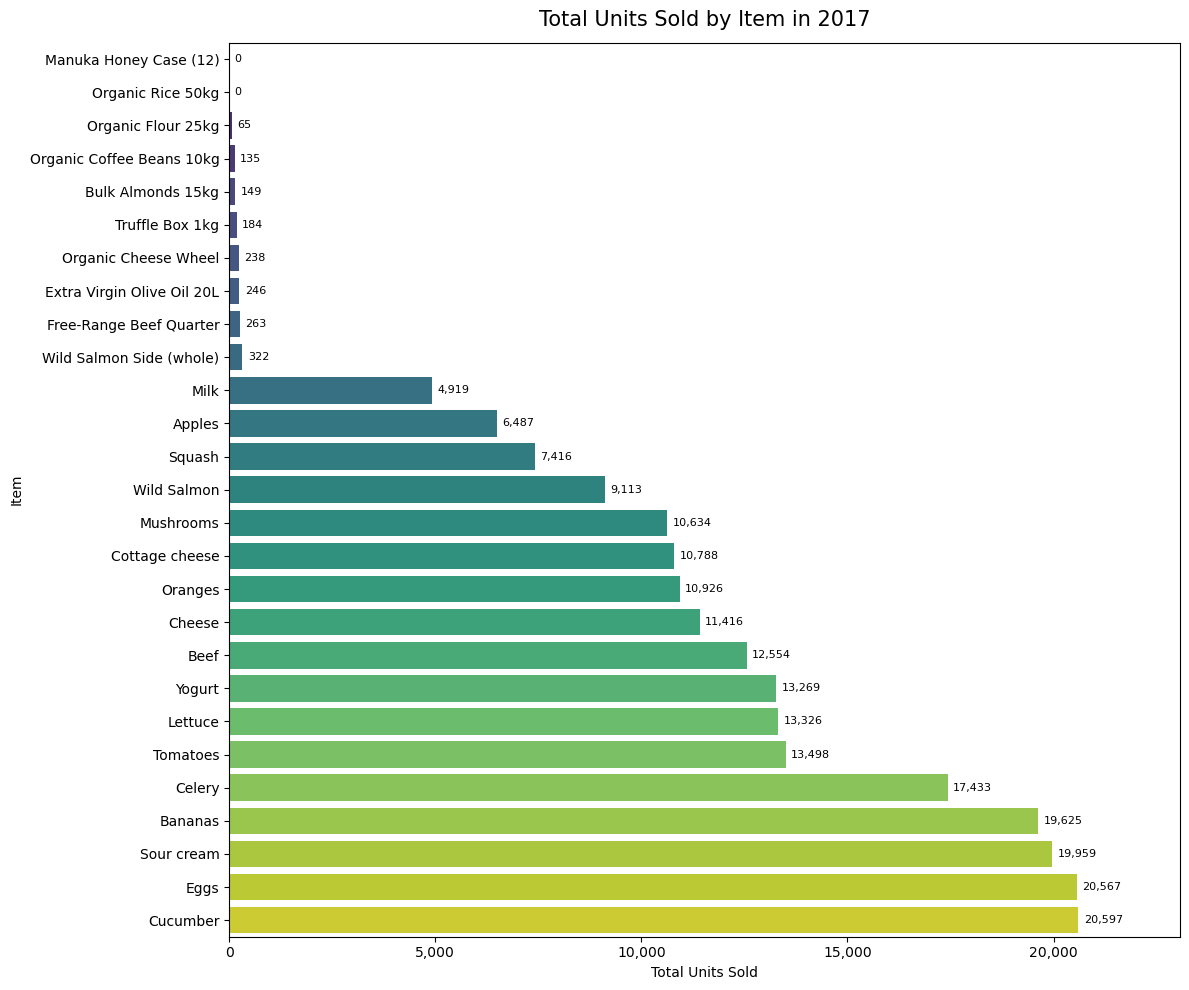

In [143]:
# Sort items from the lowest to the highest number of units sold
units_plot_data = units_sold_2017.sort_values(
    "Total Units Sold",
    ascending=True
)

plt.figure(figsize=(12, 10))

ax = sns.barplot(
    data=units_plot_data,
    x="Total Units Sold",
    y="Item",
    hue="Item",
    palette="viridis",
    legend=False
)

ax.set_title(
    "Total Units Sold by Item in 2017",
    fontsize=15,
    pad=12
)

ax.set_xlabel("Total Units Sold")
ax.set_ylabel("Item")

ax.xaxis.set_major_formatter(
    lambda value, position: f"{value:,.0f}"
)

# Add a value label to each bar
for bar in ax.patches:
    width = bar.get_width()

    if pd.notna(width):
        ax.annotate(
            f"{width:,.0f}",
            xy=(
                width,
                bar.get_y() + bar.get_height() / 2
            ),
            xytext=(4, 0),
            textcoords="offset points",
            ha="left",
            va="center",
            fontsize=8
        )

# Add extra space for the value labels
ax.margins(x=0.12)

plt.tight_layout()
plt.show()

## 17. Calculate supporting statistics

These statistics identify the five highest-selling items, their combined share of total units sold, and items with zero recorded units.

In [144]:
# Calculate the overall total units sold in 2017
total_units_2017 = units_sold_2017["Total Units Sold"].sum()

# Select the five highest-selling items
top_five_items = (
    units_sold_2017
    .nlargest(5, "Total Units Sold")
    .reset_index(drop=True)
)

# Add a ranking column
top_five_items.insert(
    0,
    "Rank",
    range(1, len(top_five_items) + 1)
)

# Calculate the total units and percentage share of the top five items
top_five_units = top_five_items["Total Units Sold"].sum()

top_five_share = (
    top_five_units
    / total_units_2017
    * 100
)

# Identify items with zero units sold
zero_sales_items = (
    units_sold_2017
    .loc[units_sold_2017["Total Units Sold"] == 0]
    .reset_index(drop=True)
)

print("Five Highest-Selling Items in 2017:")

display(
    top_five_items.style
    .format(
        {
            "Rank": "{:.0f}",
            "Total Units Sold": "{:,.0f}"
        }
    )
    .hide(axis="index")
)

# Create a summary table
summary_table = pd.DataFrame(
    {
        "Measure": [
            "Total units sold in 2017",
            "Units sold by top five items",
            "Top-five share of total units sold",
            "Number of items with zero sales"
        ],
        "Result": [
            f"{total_units_2017:,.0f}",
            f"{top_five_units:,.0f}",
            f"{top_five_share:.1f}%",
            f"{len(zero_sales_items):,.0f}"
        ]
    }
)

print("Summary of 2017 Unit Sales:")

display(
    summary_table.style
    .hide(axis="index")
)

print("Items with Zero Units Sold in 2017:")

if zero_sales_items.empty:
    print("No items recorded zero units sold in 2017.")
else:
    display(
        zero_sales_items.style
        .format(
            {
                "Total Units Sold": "{:,.0f}"
            }
        )
        .hide(axis="index")
    )

Five Highest-Selling Items in 2017:


Rank,Item,Total Units Sold
1,Cucumber,"20,597"
2,Eggs,"20,567"
3,Sour cream,"19,959"
4,Bananas,"19,625"
5,Celery,"17,433"


Summary of 2017 Unit Sales:


Measure,Result
Total units sold in 2017,"224,129"
Units sold by top five items,"98,181"
Top-five share of total units sold,43.8%
Number of items with zero sales,2


Items with Zero Units Sold in 2017:


Item,Total Units Sold
Organic Rice 50kg,0
Manuka Honey Case (12),0


## 18. Discussion of the 2017 outcome (200 Words)

2017 results show AusiFood sold 224,129 units across 27 different products but demand distribution was uneven. Cucumbers sold the most with 20,597 units followed by Eggs, Sour Cream, Bananas and Celery. Together the top five products account for roughly 43.8% of total units sold suggesting that demand is quite concentrated. Concentration of demand has important operational implications because stockouts of a small number of high volume products could have a material impact on performance and customer satisfaction. Analysis also clearly contrasts everyday frequent purchases with bulk or premium items of low volume. Organic Flour 25kg, Organic Coffee Beans 10kg, Bulk Almonds 15kg and Truffle Box 1kg each sold fewer than 200 units. Manuka Honey Cases (12) and Organic Rice 50kg did not sell anything in 2017 even though they appear elsewhere in the dataset data alone does not establish whether this was due to weak demand, introduction after 2017 or supply constraints or missing transaction activity.
From a business analytics standpoint AusiFood should focus inventory availability on high volume items separately reviewing low volume items using measures of profitability, margins, seasonality and turnover. Further analysis over multiple years would help determine whether these patterns are persistent or specific just to 2017.


## 19. Conclusion

The analysis demonstrates how Python can be used to import, clean, aggregate, and visualise business data. AusiFood’s profit increased across the period, Victoria generated the highest supplier-location profit, and 2017 unit sales were concentrated among a relatively small number of frequently purchased products.

## 20. Optional export of result tables

The result tables are exported as CSV files to provide an auditable and reproducible record of the analysis.

In [145]:
profit_by_year.to_csv("s8200703_profit_by_year.csv", index=False)
profit_by_state.to_csv("s8200703_profit_by_state.csv", index=False)
monthly_sales_by_state.to_csv("s8200703_monthly_sales_by_state.csv")
units_sold_2017.to_csv("s8200703_units_sold_2017.csv", index=False)

print("All result tables exported successfully.")

All result tables exported successfully.
